# TÉCNICO EM CIÊNCIA DE DADOS

# Roteiro de Atividade Prática

**Componente:** Inteligência Artificial  
**Unidade Curricular:** Redes Neurais  
**Tema da Semana:** Otimização e Regularização  
**Semana 5**  
**Aula 3:** Avaliação de estratégias de melhoria de desempenho


## Colocando em prática

**Missão:** analisar três experimentos com a mesma rede neural e recomendar uma configuração com base em evidências.

Nesta atividade, você vai mobilizar o que já estudou:

- **Aula 1:** otimização orienta a atualização dos parâmetros, buscando reduzir o erro;
- **Aula 2:** regularização ajuda a controlar o ajuste excessivo e favorecer a generalização;
- **Aula 3:** agora você vai **comparar resultados, interpretar evidências e tomar uma decisão**.

> **Importante:** você não precisa programar. Execute as células na ordem apresentada, observe os resultados e registre as respostas no roteiro da atividade.


## Situação profissional

Uma equipe de Ciência de Dados desenvolveu uma rede neural para classificar solicitações de manutenção de equipamentos industriais.

O modelo já funciona, mas a equipe precisa decidir se mudanças no processo de treinamento e o uso de regularização realmente contribuem para um desempenho mais adequado em **dados de validação**.

A equipe preparou três configurações:

1. **Modelo-base**
2. **Estratégia de otimização**
3. **Estratégia com regularização**

Sua dupla deverá comparar as três e recomendar uma configuração.


## Como realizar a atividade

1. Execute cada célula clicando em **▶**.
2. **Não altere o código.**
3. Observe os gráficos e tabelas.
4. Compare sempre **treinamento × validação**.
5. Registre no roteiro as respostas às perguntas apresentadas neste notebook.
6. Na decisão final, utilize **pelo menos duas evidências**.

> Os dados são simulados e foram configurados apenas para tornar os comportamentos estudados visíveis em sala de aula.


## Preparação do experimento

A célula abaixo cria um conjunto de dados simulado e define as funções utilizadas nos três experimentos.

Você não precisa interpretar o código. Apenas execute.


In [1]:
# Preparação do ambiente — não altere
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, log_loss

# Dados simulados
X, y = make_classification(
    n_samples=700,
    n_features=30,
    n_informative=5,
    n_redundant=2,
    n_classes=2,
    flip_y=0.08,
    class_sep=1.5,
    random_state=42
)

X_treino, X_validacao, y_treino, y_validacao = train_test_split(
    X, y,
    train_size=100,
    random_state=42,
    stratify=y
)

padronizador = StandardScaler().fit(X_treino)
X_treino = padronizador.transform(X_treino)
X_validacao = padronizador.transform(X_validacao)

def executar_experimento(nome, taxa_aprendizagem, regularizacao, epocas=250):
    modelo = MLPClassifier(
        hidden_layer_sizes=(64, 64),
        activation="relu",
        solver="sgd",
        learning_rate="constant",
        learning_rate_init=taxa_aprendizagem,
        alpha=regularizacao,
        momentum=0.9,
        max_iter=1,
        warm_start=True,
        random_state=42
    )

    historico = []

    for epoca in range(1, epocas + 1):
        modelo.fit(X_treino, y_treino)

        prob_treino = modelo.predict_proba(X_treino)
        prob_validacao = modelo.predict_proba(X_validacao)

        historico.append({
            "Época": epoca,
            "Perda - treino": log_loss(y_treino, prob_treino),
            "Perda - validação": log_loss(y_validacao, prob_validacao),
            "Acurácia - treino": accuracy_score(y_treino, modelo.predict(X_treino)),
            "Acurácia - validação": accuracy_score(y_validacao, modelo.predict(X_validacao))
        })

    historico = pd.DataFrame(historico)

    resumo = {
        "Configuração": nome,
        "Acurácia treino": historico.iloc[-1]["Acurácia - treino"],
        "Acurácia validação": historico.iloc[-1]["Acurácia - validação"],
        "Diferença": historico.iloc[-1]["Acurácia - treino"] - historico.iloc[-1]["Acurácia - validação"],
        "Perda treino": historico.iloc[-1]["Perda - treino"],
        "Perda validação": historico.iloc[-1]["Perda - validação"]
    }

    return historico, resumo

print("Ambiente preparado. Agora siga para o Experimento 1.")


Ambiente preparado. Agora siga para o Experimento 1.


# Experimento 1 — Modelo-base

Primeiro, observe o comportamento da configuração inicial.

A equipe utiliza uma configuração conservadora de atualização dos parâmetros. O objetivo aqui é estabelecer uma **referência** para as comparações seguintes.


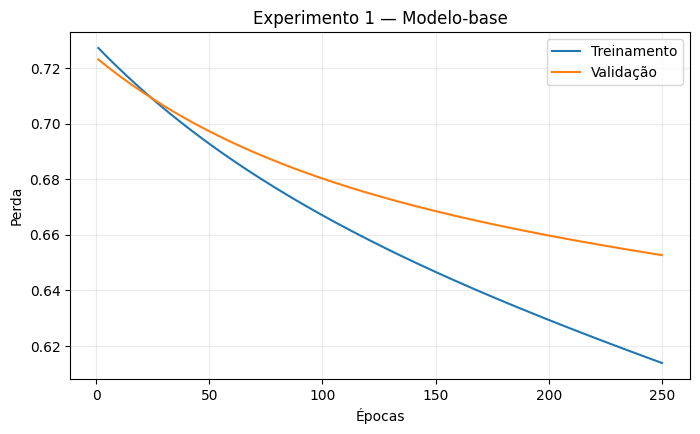

,Configuração,Acurácia treino,Acurácia validação,Diferença,Perda treino,Perda validação
0,Modelo-base,68.0%,60.7%,7.3%,0.614,0.653


In [2]:
historico_base, resumo_base = executar_experimento(
    nome="Modelo-base",
    taxa_aprendizagem=0.001,
    regularizacao=0.0
)

plt.figure(figsize=(8, 4.5))
plt.plot(historico_base["Época"], historico_base["Perda - treino"], label="Treinamento")
plt.plot(historico_base["Época"], historico_base["Perda - validação"], label="Validação")
plt.xlabel("Épocas")
plt.ylabel("Perda")
plt.title("Experimento 1 — Modelo-base")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

pd.DataFrame([resumo_base]).style.format({
    "Acurácia treino": "{:.1%}",
    "Acurácia validação": "{:.1%}",
    "Diferença": "{:.1%}",
    "Perda treino": "{:.3f}",
    "Perda validação": "{:.3f}"
})


### Registre no roteiro

**1. Que evidências os resultados do modelo-base apresentam sobre seu desempenho?**

Considere os resultados de treinamento e validação. Não avalie apenas um deles.


# Experimento 2 — Alteração na estratégia de otimização

Agora a equipe testa uma alteração na forma como o treinamento realiza as atualizações dos parâmetros.

Neste experimento, a **taxa de aprendizagem** foi ajustada. Ela controla a intensidade das atualizações realizadas durante o processo de otimização.

> Você não precisa calcular nem modificar esse valor. Observe apenas o efeito produzido nos resultados.


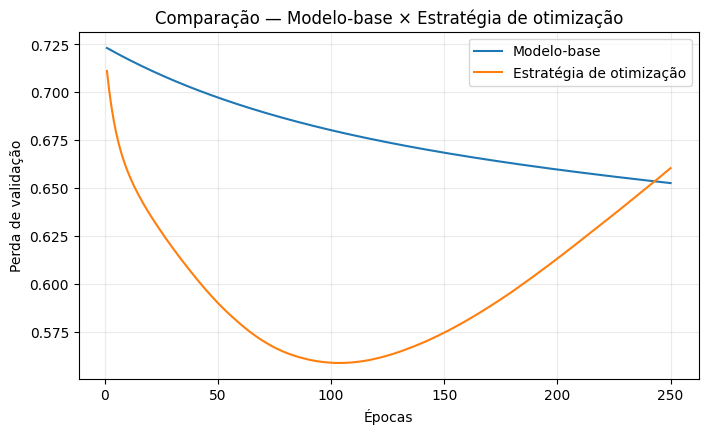

,Configuração,Acurácia treino,Acurácia validação,Diferença,Perda treino,Perda validação
0,Modelo-base,68.0%,60.7%,7.3%,0.614,0.653
1,Estratégia de otimização,99.0%,71.5%,27.5%,0.082,0.660


In [3]:
historico_otimizacao, resumo_otimizacao = executar_experimento(
    nome="Estratégia de otimização",
    taxa_aprendizagem=0.02,
    regularizacao=0.0
)

plt.figure(figsize=(8, 4.5))
plt.plot(historico_base["Época"], historico_base["Perda - validação"], label="Modelo-base")
plt.plot(historico_otimizacao["Época"], historico_otimizacao["Perda - validação"], label="Estratégia de otimização")
plt.xlabel("Épocas")
plt.ylabel("Perda de validação")
plt.title("Comparação — Modelo-base × Estratégia de otimização")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

pd.DataFrame([resumo_base, resumo_otimizacao]).style.format({
    "Acurácia treino": "{:.1%}",
    "Acurácia validação": "{:.1%}",
    "Diferença": "{:.1%}",
    "Perda treino": "{:.3f}",
    "Perda validação": "{:.3f}"
})


### Registre no roteiro

**2. O que mudou no desempenho em relação ao modelo-base?**

**3. Os resultados fornecem evidências de melhoria? Justifique utilizando os valores observados.**

> Atenção: uma estratégia não deve ser considerada melhor apenas porque reduziu o erro de treinamento. Analise também a validação.


# Experimento 3 — Regularização

No terceiro experimento, a equipe mantém a configuração de otimização anterior e adiciona **regularização L2**.

A regularização L2 aplica uma penalização associada aos parâmetros, ajudando a controlar ajustes excessivos durante o treinamento.

> O objetivo não é aprender a implementar L2. O foco é **interpretar o efeito observado**.


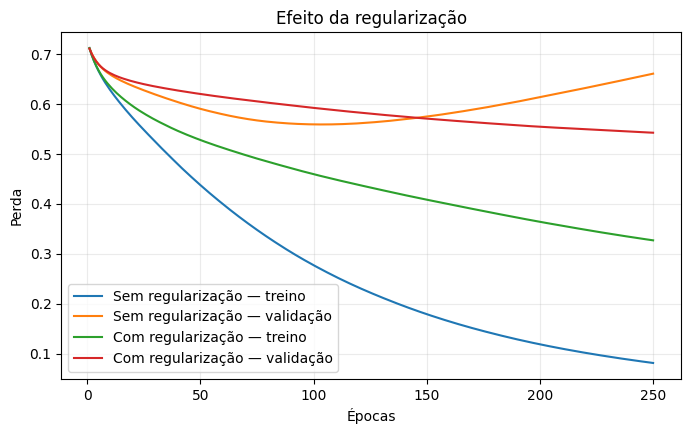

,Configuração,Acurácia treino,Acurácia validação,Diferença,Perda treino,Perda validação
0,Estratégia de otimização,99.0%,71.5%,27.5%,0.082,0.660
1,Com regularização,97.0%,74.7%,22.3%,0.327,0.542


In [4]:
historico_regularizacao, resumo_regularizacao = executar_experimento(
    nome="Com regularização",
    taxa_aprendizagem=0.02,
    regularizacao=10.0
)

plt.figure(figsize=(8, 4.5))
plt.plot(historico_otimizacao["Época"], historico_otimizacao["Perda - treino"], label="Sem regularização — treino")
plt.plot(historico_otimizacao["Época"], historico_otimizacao["Perda - validação"], label="Sem regularização — validação")
plt.plot(historico_regularizacao["Época"], historico_regularizacao["Perda - treino"], label="Com regularização — treino")
plt.plot(historico_regularizacao["Época"], historico_regularizacao["Perda - validação"], label="Com regularização — validação")
plt.xlabel("Épocas")
plt.ylabel("Perda")
plt.title("Efeito da regularização")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

pd.DataFrame([resumo_otimizacao, resumo_regularizacao]).style.format({
    "Acurácia treino": "{:.1%}",
    "Acurácia validação": "{:.1%}",
    "Diferença": "{:.1%}",
    "Perda treino": "{:.3f}",
    "Perda validação": "{:.3f}"
})


### Registre no roteiro

**4. O que aconteceu com a diferença entre o desempenho de treinamento e de validação?**

**5. Os resultados apresentam menos evidências de overfitting? Qual evidência sustenta sua resposta?**

> Não conclua que “regularização sempre melhora o modelo”. Responda a partir dos resultados deste experimento.


# Comparação final

Agora reúna as evidências dos três experimentos.

A tabela abaixo apresenta os resultados finais de cada configuração.


,Configuração,Acurácia treino,Acurácia validação,Diferença (p.p.),Perda validação
0,Modelo-base,68.0%,60.7%,7.3,0.653
1,Estratégia de otimização,99.0%,71.5%,27.5,0.660
2,Com regularização,97.0%,74.7%,22.3,0.542


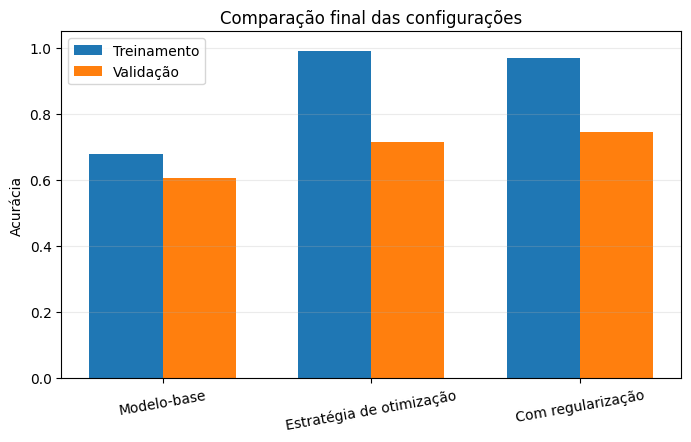

In [5]:
resumo_final = pd.DataFrame([
    resumo_base,
    resumo_otimizacao,
    resumo_regularizacao
]).copy()

resumo_final["Diferença (p.p.)"] = resumo_final["Diferença"] * 100

tabela_exibicao = resumo_final[[
    "Configuração",
    "Acurácia treino",
    "Acurácia validação",
    "Diferença (p.p.)",
    "Perda validação"
]]

display(
    tabela_exibicao.style.format({
        "Acurácia treino": "{:.1%}",
        "Acurácia validação": "{:.1%}",
        "Diferença (p.p.)": "{:.1f}",
        "Perda validação": "{:.3f}"
    })
)

plt.figure(figsize=(8, 4.5))
nomes = resumo_final["Configuração"]
x = np.arange(len(nomes))
largura = 0.35

plt.bar(x - largura/2, resumo_final["Acurácia treino"], largura, label="Treinamento")
plt.bar(x + largura/2, resumo_final["Acurácia validação"], largura, label="Validação")
plt.xticks(x, nomes, rotation=10)
plt.ylim(0, 1.05)
plt.ylabel("Acurácia")
plt.title("Comparação final das configurações")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.show()


## Decisão da equipe

**6. Qual configuração sua dupla recomendaria para utilização em novos dados? Justifique utilizando pelo menos duas evidências dos experimentos.**

Sua resposta deve:

- indicar claramente a configuração escolhida;
- utilizar resultados de **treinamento e/ou validação**;
- relacionar a decisão a **otimização, regularização, generalização ou overfitting**, quando pertinente;
- evitar justificativas como “é melhor porque tem o maior número”.


# Produto final da dupla

No roteiro, completem uma recomendação curta para a equipe de Ciência de Dados:

> **“Recomendamos a configuração __________________ porque ____________________________________. Além disso, ____________________________________. Essas evidências indicam que ________________________________________________.”**

### Antes de finalizar, verifiquem:

- [ ] Comparamos as três configurações.
- [ ] Utilizamos resultados do experimento como evidência.
- [ ] Não escolhemos apenas pelo maior resultado de treinamento.
- [ ] Relacionamos a decisão aos conceitos estudados.
- [ ] Nossa recomendação pode ser compreendida por outra equipe.


## Ideia central da prática

**Experimentar → comparar → analisar → decidir com base em evidências.**

Na Ciência de Dados, alterar um modelo não é suficiente. É preciso observar os resultados e justificar se a mudança realmente contribuiu para o desempenho desejado.
